In [22]:
import pandas as pd
# Read the data
X = pd.read_csv('train.csv', index_col='id')
X_test_full = pd.read_csv('test.csv', index_col='id')


# Remove rows with missing target, separate target from predictors
X.dropna(axis=0, subset=['Irrigation_Need'], inplace=True)
y = X['Irrigation_Need'].copy()              
X.drop(['Irrigation_Need'], axis=1, inplace=True)

In [23]:
X.shape

(630000, 19)

In [24]:
# Selecting numerical and categorical columns
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()

### Estadísticas Descriptivas


In [25]:
X.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


Se puede ver que `Rainfall_mm` es prácticamente la única variable que tiene la media relativamente lejos de la mediana.

### Matriz de Correlación


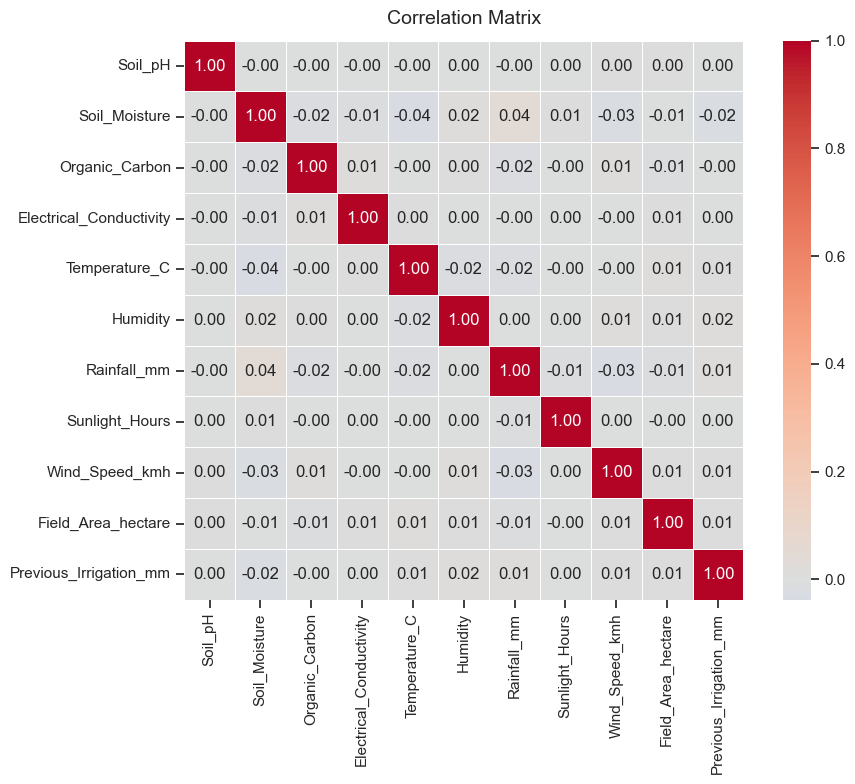

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    X[num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    ax=ax
)
ax.set_title('Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

Se ve que **no hay correlaciones fuertes** entre las variables numéricas, lo que podría significar que cada variable aporta información única al modelo. Sin embargo, también podría indicar que las variables numéricas no tienen una relación lineal fuerte entre sí, lo que no necesariamente es un problema para el modelado, pero es algo a tener en cuenta.

### Análisis de Outliers

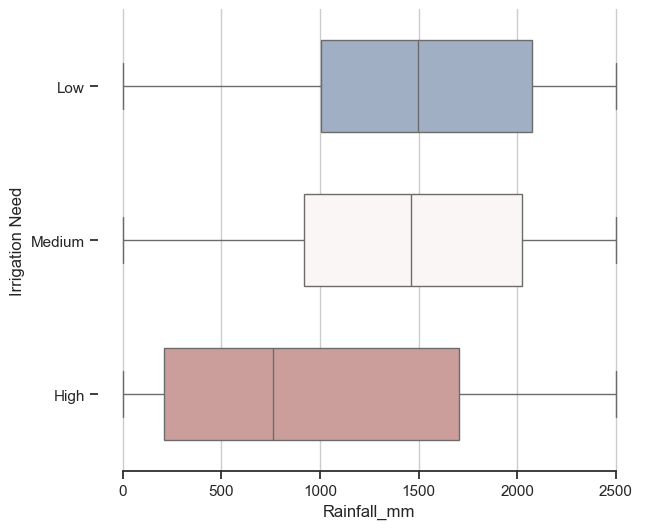

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))

# Plot the orbital period with horizontal boxes
sns.boxplot(
    pd.concat([X,y]), x="Rainfall_mm", y="Irrigation_Need",hue="Irrigation_Need",legend=False,
    whis=[0, 100], width=.6, palette="vlag"
)

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="Irrigation Need")
sns.despine(trim=True, left=True)

No parece haber realmente outliers en la variable `Rainfall_mm`

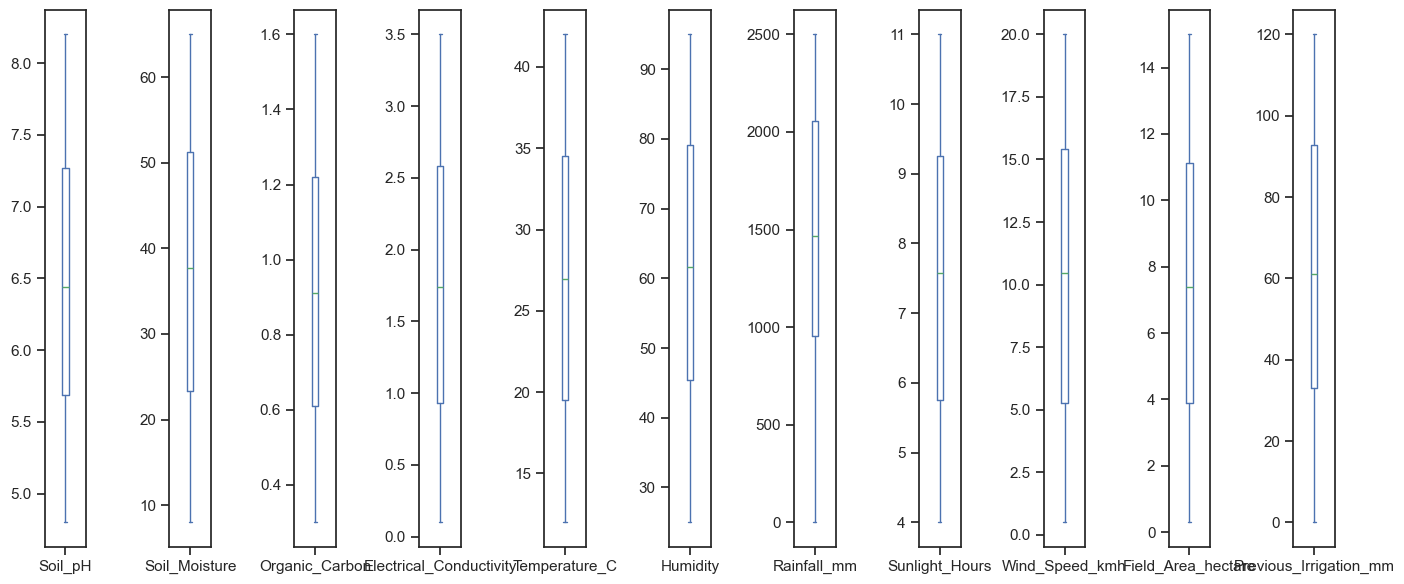

In [28]:
X[num_cols].plot(kind='box', subplots=True, figsize=(14, 6), sharey=False)
plt.tight_layout()
plt.show()

In [29]:
# Contar outliers por variable (método IQR)
for col in num_cols:
    Q1, Q3 = X[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((X[col] < Q1 - 1.5*IQR) | (X[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {outliers} outliers")

Soil_pH: 0 outliers
Soil_Moisture: 0 outliers
Organic_Carbon: 0 outliers
Electrical_Conductivity: 0 outliers
Temperature_C: 0 outliers
Humidity: 0 outliers
Rainfall_mm: 0 outliers
Sunlight_Hours: 0 outliers
Wind_Speed_kmh: 0 outliers
Field_Area_hectare: 0 outliers
Previous_Irrigation_mm: 0 outliers


### Variables Categóricas

Me llega a parecer extraño que no haya ninguna variable con desbalance de clases, finalmente, probaré con la variable target.

In [30]:
for cat in cat_cols:
    print(f"Value counts for {cat}:")
    print(X[cat].value_counts())
    print("\n")

Value counts for Soil_Type:
Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64


Value counts for Crop_Type:
Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64


Value counts for Crop_Growth_Stage:
Crop_Growth_Stage
Harvest       167689
Flowering     157563
Vegetative    157246
Sowing        147502
Name: count, dtype: int64


Value counts for Season:
Season
Kharif    216561
Rabi      208033
Zaid      205406
Name: count, dtype: int64


Value counts for Irrigation_Type:
Irrigation_Type
Canal        161901
Sprinkler    161400
Rainfed      155607
Drip         151092
Name: count, dtype: int64


Value counts for Water_Source:
Water_Source
Reservoir      162994
River          159819
Groundwater    154155
Rainwater      153032
Name: count, dtype: int64


Value counts for Mulching_Used:
Mulching_Used
No     316453
Yes    313547
Name: count, dt

In [31]:
y.value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

In [32]:
# Mostrar los % de diferencia entre clases
class_counts = y.value_counts()
class_percentages = class_counts / len(y) * 100
print("Class distribution:")
print(class_percentages)

Class distribution:
Irrigation_Need
Low       58.716984
Medium    37.948254
High       3.334762
Name: count, dtype: float64


### Desbalance de Clases

**First think:** *Efectivamente existe un desbalance de clases en y, especificamente para high que tiene 21009 muestras, investigaré en internet sobre la mejor forma de tratarlo.*

**Update:** *me dí cuenta que el 58% de las muestras pertencen a high, lo que es bastante significativo.*

**Decisión:** Primero entrenaré el modelo sin tratar el desbalance de clases, y luego probaré técnicas como *oversampling* o *undersampling* para ver si mejora el rendimiento del modelo, me llamó la atención esta información de google: [Imbalanced Datasets - Google ML Crash Course](https://developers.google.com/machine-learning/crash-course/overfitting/imbalanced-datasets?hl=es-419)